# Data Unification for Wide&Deep Recommender System
## Prototype Dataset Creation from 3 Kaggle Sources

**Goal:** Create a unified, balanced dataset for training a simulation recommendation model  
**Input:** 3 Kaggle datasets (AI Career, Career Paths, Skill & Career)  
**Output:** ~27,000 training samples (user-simulation pairs with engagement labels)

**Key Principles:**
- ✅ Global-ready (no Ecuador-specific fields)
- ✅ 5-dimension learning style profiles
- ✅ Balanced skill distribution
- ✅ Realistic engagement rates (40-50% positive)
- ✅ Positive + Negative sampling

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import Counter
import json
import random
from sklearn.preprocessing import LabelEncoder
import re

warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

# Paths
data_dir = Path('/workspace/data/raw')
output_dir = Path('/workspace/data/processed')
viz_dir = Path('/workspace/data/visualizations')
output_dir.mkdir(parents=True, exist_ok=True)
viz_dir.mkdir(parents=True, exist_ok=True)

# Random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("✓ Setup complete")
print(f"  Input: {data_dir}")
print(f"  Output: {output_dir}")
print(f"  Visualizations: {viz_dir}")

✓ Setup complete
  Input: /workspace/data/raw
  Output: /workspace/data/processed
  Visualizations: /workspace/data/visualizations


---
## Step 1: Load Raw Datasets

In [2]:
# Load datasets
df_ai = pd.read_csv(data_dir / 'ai_career.csv')
df_career = pd.read_csv(data_dir / 'career_paths.csv')
df_skill = pd.read_csv(data_dir / 'skill_career.csv')

print("Dataset Shapes:")
print(f"  AI Career:      {df_ai.shape}")
print(f"  Career Paths:   {df_career.shape}")
print(f"  Skill & Career: {df_skill.shape}")
print(f"\nTotal raw records: {len(df_ai) + len(df_career) + len(df_skill):,}")

# Preview each dataset
print("\n" + "="*80)
print("AI CAREER DATASET")
print("="*80)
display(df_ai.head(3))
print(f"\nColumns: {df_ai.columns.tolist()}")

print("\n" + "="*80)
print("CAREER PATHS DATASET")
print("="*80)
display(df_career.head(3))
print(f"\nColumns: {df_career.columns.tolist()}")

print("\n" + "="*80)
print("SKILL & CAREER DATASET")
print("="*80)
display(df_skill.head(3))
print(f"\nColumns: {df_skill.columns.tolist()}")

Dataset Shapes:
  AI Career:      (200, 8)
  Career Paths:   (5000, 6)
  Skill & Career: (3999, 21)

Total raw records: 9,199

AI CAREER DATASET


,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,1,John Doe,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,2,Jane Smith,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,3,Bob Johnson,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88



Columns: ['CandidateID', 'Name', 'Age', 'Education', 'Skills', 'Interests', 'Recommended_Career', 'Recommendation_Score']

CAREER PATHS DATASET


,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst



Columns: ['Education Level', 'Specialization', 'Skills', 'Certifications', 'CGPA/Percentage', 'Recommended Career']

SKILL & CAREER DATASET


,Sr.No.,Course,Job profession,Student,Linguistic,Musical,Bodily,Logical - Mathematical,Spatial-Visualization,Interpersonal,...,Naturalist,s/p,P1,P2,P3,P4,P5,P6,P7,P8
0,1.0,NaN,Astronomer\n,S1,11.0,5.0,12.0,16.0,17.0,11.0,...,19.0,s1,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST
1,NaN,NaN,Astronomer\n,S2,12.0,6.0,12.0,16.0,16.0,11.0,...,19.0,s2,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST
2,NaN,NaN,Astronomer\n,S3,13.0,7.0,12.0,16.0,15.0,11.0,...,19.0,s3,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST



Columns: ['Sr.No.', 'Course', 'Job profession', 'Student', 'Linguistic', 'Musical', 'Bodily', 'Logical - Mathematical', 'Spatial-Visualization', 'Interpersonal', 'Intrapersonal', 'Naturalist', 's/p', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']


---
## Step 2: Define Global Taxonomies

Create consistent mappings for careers, skills, and industries across all datasets.

In [3]:
# ===== CAREER CATEGORIES =====
CAREER_CATEGORIES = {
    'STEM': [
        'Software Engineer', 'ML Engineer', 'Data Scientist', 'Research Scientist',
        'AI Engineer', 'DevOps Engineer', 'Cloud Architect', 'Backend Developer',
        'Frontend Developer', 'Full Stack Developer', 'Data Analyst', 'Data Engineer',
        'Astronomer', 'Geologist', 'Research analyst', 'Research Analyst',
        'Software Developer', 'Systems Engineer', 'Database Administrator'
    ],
    'Business': [
        'Marketing Executive', 'Product Manager', 'Business Analyst',
        'Project Manager', 'Consultant', 'Marketing', 'Logistics manager',
        'Operations Manager', 'Supply Chain Manager', 'Business Development',
        'Sales Manager', 'HR Manager', 'Logistics Manager'
    ],
    'Finance': [
        'Financial Analyst', 'Accountant', 'Investment Banker',
        'Clerk', 'Auditor', 'Tax Consultant', 'Finance Manager',
        'Risk Analyst', 'Portfolio Manager'
    ],
    'Health': [
        'Doctor', 'Nurse', 'Psychologist', 'Therapist',
        'Healthcare Administrator', 'Medical Researcher', 'Clinical Psychologist'
    ],
    'Design': [
        'UX Designer', 'UI Designer', 'Graphic Designer',
        'Product Designer', 'Creative Director', 'Web Designer'
    ],
    'Legal': [
        'Lawyer', 'Legal Advisor', 'Paralegal', 'Attorney'
    ],
    'Education': [
        'Teacher', 'Professor', 'Trainer', 'Instructional Designer',
        'Education Coordinator'
    ]
}

# Create reverse mapping
career_to_category = {}
for category, careers in CAREER_CATEGORIES.items():
    for career in careers:
        career_to_category[career.lower()] = category

def map_career_to_category(career_name):
    """Map any career to its category, default to 'Other'"""
    if pd.isna(career_name):
        return 'Other'
    career_clean = str(career_name).strip().lower()
    return career_to_category.get(career_clean, 'Other')

print("Career Categories Defined:")
for cat, careers in CAREER_CATEGORIES.items():
    print(f"  {cat:12s}: {len(careers):2d} careers")

# ===== FIELD OF STUDY MAPPING =====
FIELD_MAPPING = {
    'engineering': 'Engineering',
    'computer science': 'Computer Science',
    'finance': 'Finance',
    'business': 'Business',
    'psychology': 'Psychology',
    'health': 'Health Sciences',
    'design': 'Design',
    'marketing': 'Business',
    'data science': 'Computer Science'
}

# ===== INDUSTRY MAPPING =====
CATEGORY_TO_INDUSTRY = {
    'STEM': 'Technology',
    'Business': 'Business & Management',
    'Finance': 'Finance & Banking',
    'Health': 'Healthcare',
    'Design': 'Creative & Design',
    'Legal': 'Legal Services',
    'Education': 'Education'
}

print("\n✓ Taxonomies defined")

Career Categories Defined:
  STEM        : 19 careers
  Business    : 13 careers
  Finance     :  9 careers
  Health      :  7 careers
  Design      :  6 careers
  Legal       :  4 careers
  Education   :  5 careers

✓ Taxonomies defined


---
## Step 3: Build Skills Catalog

Extract all unique skills from all datasets and analyze distribution.

Total skill occurrences: 5,602
Unique skills (raw): 831

Top 20 Most Common Skills (BEFORE rebalancing):
  Python                        :   254
  Accounting                    :   204
  SQL                           :   188
  Data Analysis                 :   185
  Financial Analysis            :   182
  Machine Learning              :   178
  Communication                 :   168
  Marketing                     :   168
  MS Office                     :   167
  Counseling                    :   162
  SQL, Data Analysis            :    30
  Data Analysis, MS Office      :    29
  Counseling, Python            :    26
  Financial Analysis, SQL       :    26
  Machine Learning, Accounting  :    25
  MS Office, Accounting         :    25
  Financial Analysis, Machine Learning:    25
  Python, Accounting            :    23
  SQL, Marketing                :    23
  MS Office, Python             :    23


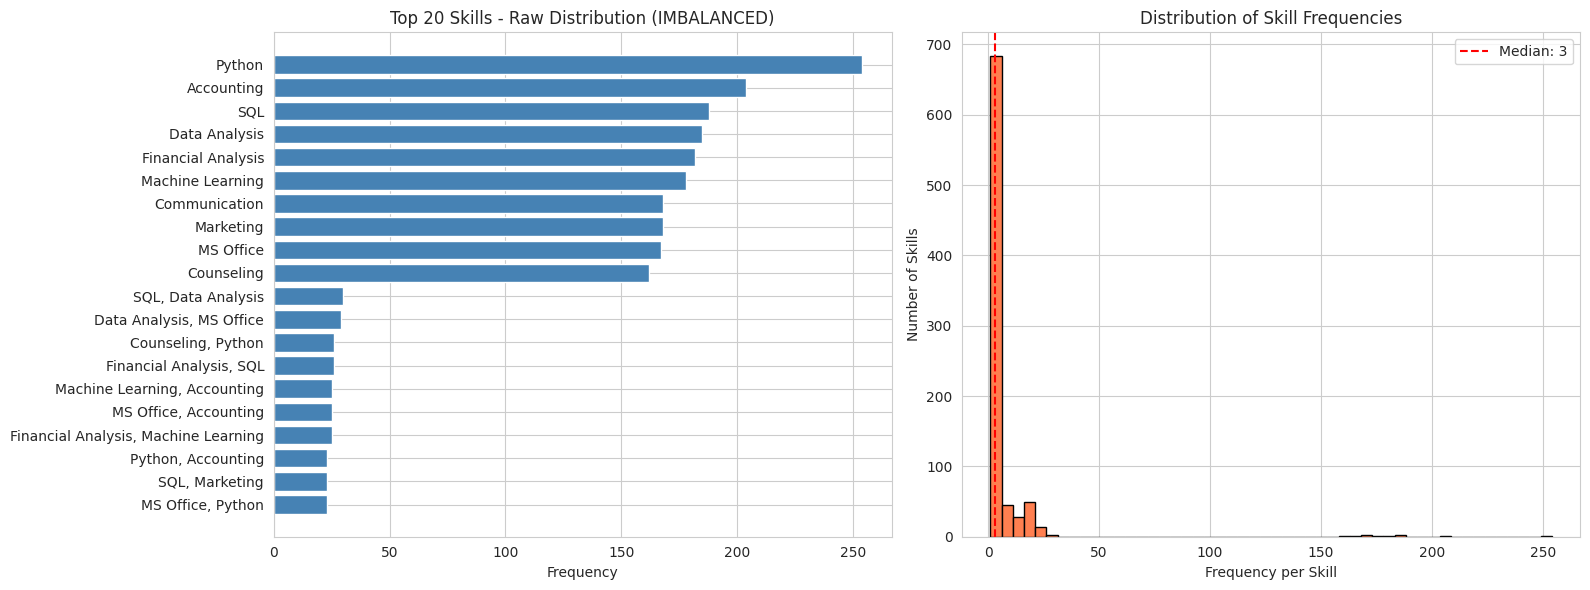


⚠️  IMBALANCE DETECTED:
  Most common skill: 254 occurrences
  Median skill: 3 occurrences
  Least common skill: 1 occurrences
  Ratio (max/median): 84.7x


In [4]:
# Extract skills from each dataset
all_skills_raw = []

# From AI Career (semicolon-separated)
for skills_str in df_ai['Skills'].dropna():
    skills = [s.strip() for s in str(skills_str).split(';')]
    all_skills_raw.extend(skills)

# From Career Paths (single skill per row)
for skill in df_career['Skills'].dropna():
    all_skills_raw.append(str(skill).strip())

# From Skill & Career (infer from Job profession)
# We'll add these later with inference

print(f"Total skill occurrences: {len(all_skills_raw):,}")
print(f"Unique skills (raw): {len(set(all_skills_raw))}")

# Count skill frequency
skill_counter = Counter(all_skills_raw)
print(f"\nTop 20 Most Common Skills (BEFORE rebalancing):")
for skill, count in skill_counter.most_common(20):
    print(f"  {skill:30s}: {count:5d}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 skills
top_20 = skill_counter.most_common(20)
skills_names = [s[0] for s in top_20]
skills_counts = [s[1] for s in top_20]

axes[0].barh(skills_names, skills_counts, color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Skills - Raw Distribution (IMBALANCED)')
axes[0].invert_yaxis()

# Histogram of skill frequencies
all_counts = list(skill_counter.values())
axes[1].hist(all_counts, bins=50, color='coral', edgecolor='black')
axes[1].set_xlabel('Frequency per Skill')
axes[1].set_ylabel('Number of Skills')
axes[1].set_title('Distribution of Skill Frequencies')
axes[1].axvline(np.median(all_counts), color='red', linestyle='--', label=f'Median: {np.median(all_counts):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(viz_dir / '01_raw_skill_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n⚠️  IMBALANCE DETECTED:")
print(f"  Most common skill: {skill_counter.most_common(1)[0][1]:,} occurrences")
print(f"  Median skill: {np.median(all_counts):.0f} occurrences")
print(f"  Least common skill: {min(all_counts)} occurrences")
print(f"  Ratio (max/median): {skill_counter.most_common(1)[0][1] / np.median(all_counts):.1f}x")

---
## Step 4: Career-to-Skills Inference Rules

Define systematic rules to infer additional skills based on career paths.

In [5]:
# Define skill inference rules for each career
CAREER_SKILL_RULES = {
    # STEM Careers
    'Software Engineer': {
        'always': ['Python', 'Problem Solving', 'Git'],
        'common': ['JavaScript', 'SQL', 'Teamwork'],  # 60% probability
        'rare': ['Communication', 'Leadership']  # 30% probability
    },
    'Data Scientist': {
        'always': ['Python', 'Statistics', 'Machine Learning'],
        'common': ['SQL', 'Data Analysis', 'R'],
        'rare': ['Communication', 'Data Visualization']
    },
    'ML Engineer': {
        'always': ['Python', 'Machine Learning', 'Deep Learning'],
        'common': ['TensorFlow', 'Statistics', 'Problem Solving'],
        'rare': ['Communication']
    },
    'Data Analyst': {
        'always': ['Excel', 'Data Analysis', 'SQL'],
        'common': ['Python', 'Statistics', 'Tableau'],
        'rare': ['Communication', 'Problem Solving']
    },
    
    # Business Careers
    'Marketing Executive': {
        'always': ['Marketing', 'Communication', 'Social Media'],
        'common': ['Data Analysis', 'Creativity', 'Teamwork'],
        'rare': ['SEO', 'Content Creation']
    },
    'Product Manager': {
        'always': ['Product Management', 'Leadership', 'Communication'],
        'common': ['Data Analysis', 'Problem Solving', 'Teamwork'],
        'rare': ['SQL', 'UX Design']
    },
    'Business Analyst': {
        'always': ['Business Analysis', 'Excel', 'Data Analysis'],
        'common': ['SQL', 'Communication', 'Problem Solving'],
        'rare': ['Python', 'Tableau']
    },
    
    # Finance Careers
    'Financial Analyst': {
        'always': ['Financial Analysis', 'Excel', 'Accounting'],
        'common': ['Data Analysis', 'Problem Solving', 'Communication'],
        'rare': ['Python', 'SQL']
    },
    'Accountant': {
        'always': ['Accounting', 'Excel', 'Financial Analysis'],
        'common': ['Attention to Detail', 'Problem Solving'],
        'rare': ['Communication', 'Teamwork']
    },
    
    # Design Careers
    'UX Designer': {
        'always': ['UX Design', 'Figma', 'User Research'],
        'common': ['Creativity', 'Communication', 'Problem Solving'],
        'rare': ['HTML', 'CSS']
    },
    'Graphic Designer': {
        'always': ['Graphic Design', 'Adobe Photoshop', 'Creativity'],
        'common': ['Adobe Illustrator', 'Communication'],
        'rare': ['Branding', 'Typography']
    },
    
    # Default fallback
    'DEFAULT': {
        'always': ['Problem Solving'],
        'common': ['Communication', 'Teamwork'],
        'rare': []
    }
}

def infer_skills_for_career(career_name, existing_skills=None):
    """
    Infer additional skills for a career based on rules.
    
    Args:
        career_name: Career name (e.g., 'Software Engineer')
        existing_skills: List of skills already assigned
    
    Returns:
        List of skill names
    """
    if existing_skills is None:
        existing_skills = []
    
    skills = set(existing_skills)
    
    # Get rules for this career
    rules = CAREER_SKILL_RULES.get(career_name, CAREER_SKILL_RULES['DEFAULT'])
    
    # Always add these skills
    skills.update(rules['always'])
    
    # 60% chance to add common skills
    for skill in rules['common']:
        if random.random() < 0.6:
            skills.add(skill)
    
    # 30% chance to add rare skills
    for skill in rules['rare']:
        if random.random() < 0.3:
            skills.add(skill)
    
    return list(skills)

print(f"Career-to-Skills inference rules defined for {len(CAREER_SKILL_RULES)} careers")
print("\nExample: Software Engineer skills")
example_skills = infer_skills_for_career('Software Engineer', existing_skills=['Java'])
print(f"  Input: ['Java']")
print(f"  Output: {example_skills}")

Career-to-Skills inference rules defined for 12 careers

Example: Software Engineer skills
  Input: ['Java']
  Output: ['Problem Solving', 'Git', 'Teamwork', 'Communication', 'Python', 'SQL', 'Java']


---
## Step 5: Learning Style Inference Rules

Map careers and skills to 5-dimensional learning style scores.

Learning Style Profiles by Category:


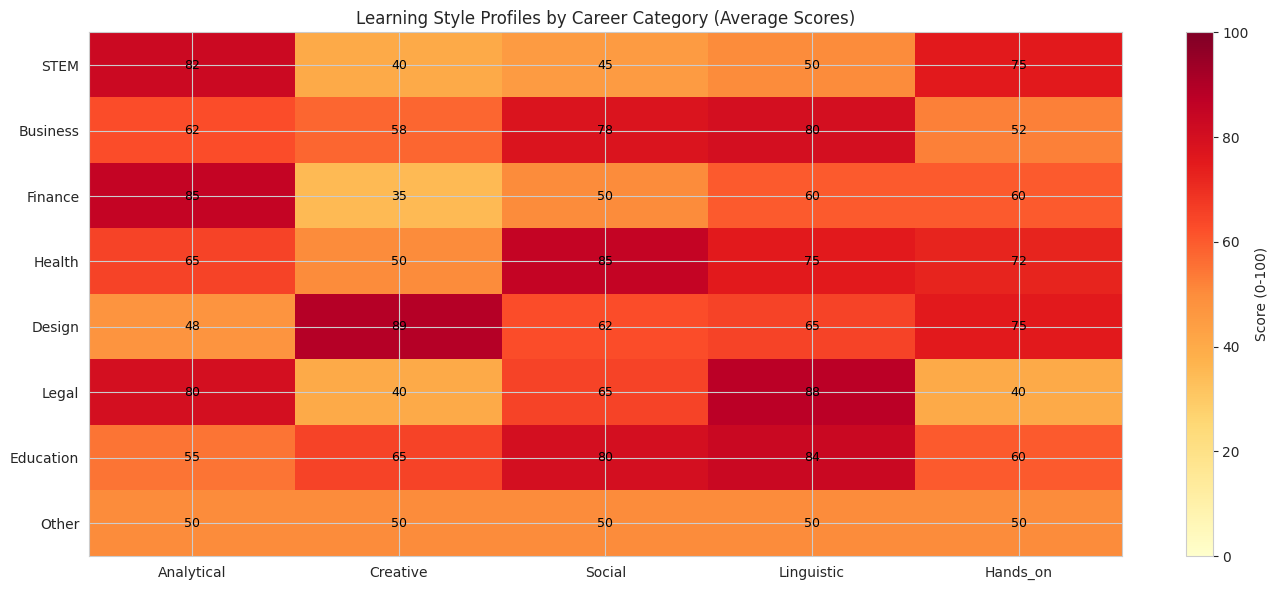


✓ Learning style inference rules defined


In [6]:
# Define learning style profiles for each category
CATEGORY_LEARNING_PROFILES = {
    'STEM': {
        'analytical': (70, 95),      # High analytical (range for random)
        'creative': (30, 50),        # Low-medium creative
        'social': (30, 60),          # Low-medium social
        'linguistic': (40, 60),      # Medium linguistic
        'hands_on': (60, 90)         # High hands-on
    },
    'Business': {
        'analytical': (50, 75),
        'creative': (45, 70),
        'social': (65, 90),          # High social
        'linguistic': (70, 90),      # High linguistic
        'hands_on': (40, 65)
    },
    'Finance': {
        'analytical': (75, 95),      # Very high analytical
        'creative': (25, 45),
        'social': (40, 60),
        'linguistic': (50, 70),
        'hands_on': (50, 70)
    },
    'Health': {
        'analytical': (55, 75),
        'creative': (40, 60),
        'social': (75, 95),          # Very high social (empathy)
        'linguistic': (65, 85),
        'hands_on': (60, 85)
    },
    'Design': {
        'analytical': (35, 60),
        'creative': (80, 98),        # Very high creative
        'social': (50, 75),
        'linguistic': (55, 75),
        'hands_on': (65, 85)
    },
    'Legal': {
        'analytical': (70, 90),
        'creative': (30, 50),
        'social': (55, 75),
        'linguistic': (80, 95),      # Very high linguistic
        'hands_on': (30, 50)
    },
    'Education': {
        'analytical': (45, 65),
        'creative': (55, 75),
        'social': (70, 90),
        'linguistic': (75, 92),
        'hands_on': (50, 70)
    },
    'Other': {
        'analytical': (40, 60),
        'creative': (40, 60),
        'social': (40, 60),
        'linguistic': (40, 60),
        'hands_on': (40, 60)
    }
}

def infer_learning_scores(category, base_scores=None):
    """
    Generate learning style scores for a given category.
    
    Args:
        category: Career category (e.g., 'STEM')
        base_scores: Dict of existing scores (from Skill & Career dataset)
    
    Returns:
        Dict with 5 learning scores (0-100)
    """
    profile = CATEGORY_LEARNING_PROFILES.get(category, CATEGORY_LEARNING_PROFILES['Other'])
    
    scores = {}
    for dimension, (min_val, max_val) in profile.items():
        # If we have base scores, add noise instead of generating from scratch
        if base_scores and dimension in base_scores:
            base = base_scores[dimension]
            # Add noise ±10 but keep within category range
            noise = np.random.randint(-10, 11)
            score = np.clip(base + noise, min_val, max_val)
        else:
            # Generate random score within category range
            score = np.random.randint(min_val, max_val + 1)
        
        scores[dimension] = score
    
    return scores

# Visualize learning profiles
print("Learning Style Profiles by Category:")
print("="*80)

categories = list(CATEGORY_LEARNING_PROFILES.keys())
dimensions = ['analytical', 'creative', 'social', 'linguistic', 'hands_on']

# Calculate average for each category
avg_profiles = {}
for cat in categories:
    profile = CATEGORY_LEARNING_PROFILES[cat]
    avg_profiles[cat] = {
        dim: (profile[dim][0] + profile[dim][1]) / 2 
        for dim in dimensions
    }

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 6))

data = [[avg_profiles[cat][dim] for dim in dimensions] for cat in categories]
im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(np.arange(len(dimensions)))
ax.set_yticks(np.arange(len(categories)))
ax.set_xticklabels([d.capitalize() for d in dimensions])
ax.set_yticklabels(categories)

# Add values to cells
for i in range(len(categories)):
    for j in range(len(dimensions)):
        text = ax.text(j, i, f"{data[i][j]:.0f}",
                      ha="center", va="center", color="black", fontsize=9)

ax.set_title('Learning Style Profiles by Career Category (Average Scores)')
plt.colorbar(im, ax=ax, label='Score (0-100)')
plt.tight_layout()
plt.savefig(viz_dir / '02_learning_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Learning style inference rules defined")

---
## Step 6: Transform AI Career Dataset

In [7]:
def transform_ai_career_dataset(df):
    """
    Transform AI Career dataset into user profiles.
    """
    user_profiles = []
    
    for idx, row in df.iterrows():
        # Parse skills from semicolon-separated string
        skills_raw = str(row['Skills']).split(';')
        skills_clean = [s.strip() for s in skills_raw if s.strip()]
        
        # Map career to category
        career = row['Recommended_Career']
        category = map_career_to_category(career)
        
        # Infer additional skills based on career
        all_skills = infer_skills_for_career(career, existing_skills=skills_clean)
        
        # Education mapping
        education_map = {
            "Bachelor's": "Bachelor's",
            "Master's": "Master's",
            "PhD": "PhD"
        }
        education = education_map.get(row['Education'], "Bachelor's")
        
        # Field of study (infer from career)
        if category == 'STEM':
            field = 'Computer Science'
        elif category == 'Business':
            field = 'Business'
        elif category == 'Finance':
            field = 'Finance'
        elif category == 'Health':
            field = 'Health Sciences'
        elif category == 'Design':
            field = 'Design'
        else:
            field = 'General Studies'
        
        # Generate learning scores
        learning_scores = infer_learning_scores(category)
        
        # Create user profile
        profile = {
            'user_id': f'ai_{idx}',
            'source_dataset': 'ai_career',
            
            # Skills
            'skills': all_skills,
            
            # Education
            'education_level': education,
            'field_of_study': field,
            
            # Learning style (5 dimensions)
            'analytical_score': learning_scores['analytical'],
            'creative_score': learning_scores['creative'],
            'social_score': learning_scores['social'],
            'linguistic_score': learning_scores['linguistic'],
            'hands_on_score': learning_scores['hands_on'],
            
            # Recommended career (for creating positive samples)
            'recommended_career': career,
            'recommended_category': category,
            
            # Engagement score (original recommendation score)
            'base_engagement_score': row['Recommendation_Score']
        }
        
        user_profiles.append(profile)
    
    return user_profiles

# Transform dataset
print("Transforming AI Career dataset...")
ai_profiles = transform_ai_career_dataset(df_ai)
print(f"✓ Created {len(ai_profiles)} user profiles")

# Show examples
print("\nExample User Profile:")
print(json.dumps(ai_profiles[0], indent=2))

# Analyze distributions
df_ai_profiles = pd.DataFrame(ai_profiles)

print("\nCategory Distribution:")
print(df_ai_profiles['recommended_category'].value_counts())

print("\nEducation Distribution:")
print(df_ai_profiles['education_level'].value_counts())

print("\nLearning Scores Summary:")
score_cols = ['analytical_score', 'creative_score', 'social_score', 'linguistic_score', 'hands_on_score']
print(df_ai_profiles[score_cols].describe())

Transforming AI Career dataset...
✓ Created 200 user profiles

Example User Profile:
{
  "user_id": "ai_0",
  "source_dataset": "ai_career",
  "skills": [
    "Data Analysis",
    "Python",
    "Data Visualization",
    "Statistics",
    "Machine Learning",
    "R"
  ],
  "education_level": "Bachelor's",
  "field_of_study": "Computer Science",
  "analytical_score": 76,
  "creative_score": 49,
  "social_score": 58,
  "linguistic_score": 54,
  "hands_on_score": 70,
  "recommended_career": "Data Scientist",
  "recommended_category": "STEM",
  "base_engagement_score": 0.95
}

Category Distribution:
recommended_category
Other       90
STEM        66
Design      21
Business    15
Finance      8
Name: count, dtype: int64

Education Distribution:
education_level
Bachelor's    92
Master's      72
PhD           36
Name: count, dtype: int64

Learning Scores Summary:
       analytical_score  creative_score  social_score  linguistic_score  \
count        200.000000      200.000000    200.000000    

---
## Step 7: Transform Career Paths Dataset

In [8]:
def transform_career_paths_dataset(df):
    """
    Transform Career Paths dataset into user profiles.
    """
    user_profiles = []
    
    for idx, row in df.iterrows():
        # Single skill per row
        skills_raw = [str(row['Skills']).strip()]
        
        # Map career to category
        career = row['Recommended Career']
        category = map_career_to_category(career)
        
        # Infer additional skills
        all_skills = infer_skills_for_career(career, existing_skills=skills_raw)
        
        # Education mapping
        education_map = {
            'Matric': 'High School',
            'Intermediate': 'High School',
            "Bachelor's": "Bachelor's",
            "Master's": "Master's",
            "PhD": "PhD"
        }
        education = education_map.get(row['Education Level'], "Bachelor's")
        
        # Field of study from Specialization
        field = row['Specialization']
        
        # Generate learning scores
        learning_scores = infer_learning_scores(category)
        
        # Normalize CGPA to 0-1 score
        cgpa = row['CGPA/Percentage']
        engagement_score = cgpa / 100.0
        
        profile = {
            'user_id': f'cp_{idx}',
            'source_dataset': 'career_paths',
            'skills': all_skills,
            'education_level': education,
            'field_of_study': field,
            'analytical_score': learning_scores['analytical'],
            'creative_score': learning_scores['creative'],
            'social_score': learning_scores['social'],
            'linguistic_score': learning_scores['linguistic'],
            'hands_on_score': learning_scores['hands_on'],
            'recommended_career': career,
            'recommended_category': category,
            'base_engagement_score': engagement_score
        }
        
        user_profiles.append(profile)
    
    return user_profiles

# Transform dataset
print("Transforming Career Paths dataset...")
cp_profiles = transform_career_paths_dataset(df_career)
print(f"✓ Created {len(cp_profiles)} user profiles")

# Analyze
df_cp_profiles = pd.DataFrame(cp_profiles)

print("\nCategory Distribution:")
print(df_cp_profiles['recommended_category'].value_counts())

print("\nField of Study Distribution:")
print(df_cp_profiles['field_of_study'].value_counts())

print("\nEngagement Score Distribution:")
print(df_cp_profiles['base_engagement_score'].describe())

Transforming Career Paths dataset...
✓ Created 5000 user profiles

Category Distribution:
recommended_category
Other        1656
STEM         1265
Finance       845
Business      827
Education     407
Name: count, dtype: int64

Field of Study Distribution:
field_of_study
Engineering         668
Finance             659
Psychology          657
Business            634
Computer Science    609
Arts                604
Commerce            601
Science             568
Name: count, dtype: int64

Engagement Score Distribution:
count    5000.000000
mean        0.774798
std         0.103963
min         0.600000
25%         0.680000
50%         0.770000
75%         0.870000
max         0.950000
Name: base_engagement_score, dtype: float64


---
## Step 8: Transform Skill & Career Dataset

In [9]:
def transform_skill_career_dataset(df):
    """
    Transform Skill & Career dataset into user profiles.
    This dataset has ACTUAL psychometric scores!
    """
    user_profiles = []
    
    # Drop rows with missing Job profession
    df_clean = df.dropna(subset=['Job profession'])
    
    for idx, row in df_clean.iterrows():
        career = row['Job profession']
        category = map_career_to_category(career)
        
        # Infer skills from career
        all_skills = infer_skills_for_career(career, existing_skills=[])
        
        # Education from Course number
        course = row['Course'] if pd.notna(row['Course']) else 3
        if course <= 1:
            education = 'High School'
        elif course <= 2:
            education = 'High School'
        elif course <= 3:
            education = "Bachelor's"
        elif course <= 4:
            education = "Master's"
        else:
            education = "PhD"
        
        # Field from career
        if category == 'STEM':
            field = 'Computer Science'
        elif category == 'Business':
            field = 'Business'
        elif category == 'Finance':
            field = 'Finance'
        else:
            field = 'General Studies'
        
        # ACTUAL PSYCHOMETRIC SCORES from dataset!
        # Map to our 5 dimensions (scale from 0-10 to 0-100)
        base_scores = {
            'linguistic': row['Linguistic'] * 10 if pd.notna(row['Linguistic']) else 50,
            'analytical': row['Logical - Mathematical'] * 10 if pd.notna(row['Logical - Mathematical']) else 50,
            'hands_on': row['Bodily'] * 10 if pd.notna(row['Bodily']) else 50,
            'social': row['Interpersonal'] * 10 if pd.notna(row['Interpersonal']) else 50,
            'creative': row['Spatial-Visualization'] * 10 if pd.notna(row['Spatial-Visualization']) else 50,
        }
        
        # Use actual scores with category-based adjustment
        learning_scores = infer_learning_scores(category, base_scores=base_scores)
        
        # Performance score from P1 (BEST=1, AVG=0.5, POOR=0.2)
        p1 = row['P1'] if pd.notna(row['P1']) else 'AVG'
        if p1 == 'BEST':
            engagement_score = np.random.uniform(0.8, 0.95)
        elif p1 == 'AVG':
            engagement_score = np.random.uniform(0.5, 0.75)
        else:  # POOR
            engagement_score = np.random.uniform(0.2, 0.45)
        
        profile = {
            'user_id': f'sc_{idx}',
            'source_dataset': 'skill_career',
            'skills': all_skills,
            'education_level': education,
            'field_of_study': field,
            'analytical_score': int(learning_scores['analytical']),
            'creative_score': int(learning_scores['creative']),
            'social_score': int(learning_scores['social']),
            'linguistic_score': int(learning_scores['linguistic']),
            'hands_on_score': int(learning_scores['hands_on']),
            'recommended_career': career,
            'recommended_category': category,
            'base_engagement_score': engagement_score
        }
        
        user_profiles.append(profile)
    
    return user_profiles

# Transform dataset
print("Transforming Skill & Career dataset...")
sc_profiles = transform_skill_career_dataset(df_skill)
print(f"✓ Created {len(sc_profiles)} user profiles")

# Analyze
df_sc_profiles = pd.DataFrame(sc_profiles)

print("\nCategory Distribution:")
print(df_sc_profiles['recommended_category'].value_counts())

print("\nLearning Scores (from ACTUAL psychometric data!):")
score_cols = ['analytical_score', 'creative_score', 'social_score', 'linguistic_score', 'hands_on_score']
print(df_sc_profiles[score_cols].describe())

Transforming Skill & Career dataset...
✓ Created 3600 user profiles

Category Distribution:
recommended_category
Other       3100
Business     200
STEM         150
Legal         50
Design        50
Health        50
Name: count, dtype: int64

Learning Scores (from ACTUAL psychometric data!):
       analytical_score  creative_score  social_score  linguistic_score  \
count       3600.000000     3600.000000   3600.000000       3600.000000   
mean          62.703333       59.138611     62.435000         62.312222   
std            8.618414        6.627966      8.311569          8.849755   
min           40.000000       40.000000     40.000000         40.000000   
25%           60.000000       60.000000     60.000000         60.000000   
50%           60.000000       60.000000     60.000000         60.000000   
75%           60.000000       60.000000     60.000000         60.000000   
max           95.000000       98.000000     95.000000         95.000000   

       hands_on_score  
count   

---
## Step 9: Combine All User Profiles

Total User Profiles: 8,800
  From AI Career:      200
  From Career Paths:   5,000
  From Skill & Career: 3,600

COMBINED USER PROFILES - ANALYSIS

Category Distribution (Combined):
recommended_category
Other        4846
STEM         1481
Business     1042
Finance       853
Education     407
Design         71
Legal          50
Health         50
Name: count, dtype: int64

Education Level Distribution:
education_level
Bachelor's     4713
High School    1987
Master's       1100
PhD            1000
Name: count, dtype: int64

Engagement Score Distribution:
count    8800.000000
mean        0.725585
std         0.160959
min         0.200803
25%         0.631054
50%         0.737942
75%         0.860000
max         0.950000
Name: base_engagement_score, dtype: float64


IndexError: index 2 is out of bounds for axis 0 with size 2

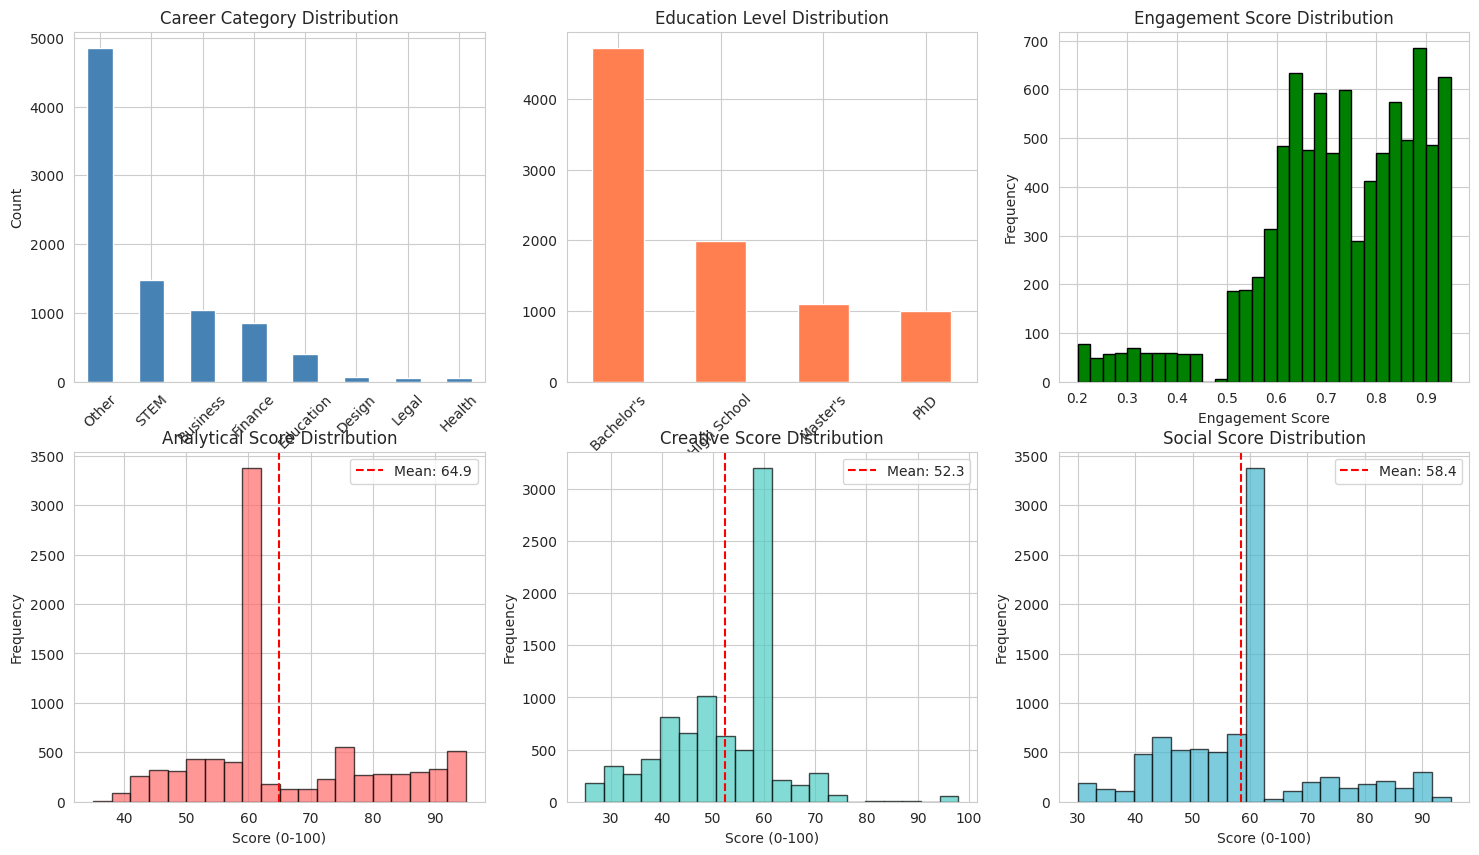

In [10]:
# Combine all profiles
all_user_profiles = ai_profiles + cp_profiles + sc_profiles

print(f"Total User Profiles: {len(all_user_profiles):,}")
print(f"  From AI Career:      {len(ai_profiles):,}")
print(f"  From Career Paths:   {len(cp_profiles):,}")
print(f"  From Skill & Career: {len(sc_profiles):,}")

# Convert to DataFrame for analysis
df_all_profiles = pd.DataFrame(all_user_profiles)

print("\n" + "="*80)
print("COMBINED USER PROFILES - ANALYSIS")
print("="*80)

print("\nCategory Distribution (Combined):")
print(df_all_profiles['recommended_category'].value_counts())

print("\nEducation Level Distribution:")
print(df_all_profiles['education_level'].value_counts())

print("\nEngagement Score Distribution:")
print(df_all_profiles['base_engagement_score'].describe())

# Visualize combined distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Category distribution
df_all_profiles['recommended_category'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Career Category Distribution')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# Education distribution
df_all_profiles['education_level'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Education Level Distribution')
axes[0,1].set_xlabel('Education')
axes[0,1].tick_params(axis='x', rotation=45)

# Engagement score distribution
axes[0,2].hist(df_all_profiles['base_engagement_score'], bins=30, color='green', edgecolor='black')
axes[0,2].set_title('Engagement Score Distribution')
axes[0,2].set_xlabel('Engagement Score')
axes[0,2].set_ylabel('Frequency')

# Learning scores distributions
score_cols = ['analytical_score', 'creative_score', 'social_score', 'linguistic_score', 'hands_on_score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for i, (col, color) in enumerate(zip(score_cols, colors)):
    row = (i + 3) // 3
    col_idx = (i + 3) % 3
    axes[row, col_idx].hist(df_all_profiles[col], bins=20, color=color, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[row, col_idx].set_xlabel('Score (0-100)')
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].axvline(df_all_profiles[col].mean(), color='red', linestyle='--', 
                               label=f'Mean: {df_all_profiles[col].mean():.1f}')
    axes[row, col_idx].legend()

plt.tight_layout()
plt.savefig(viz_dir / '03_combined_user_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ User profiles combined and analyzed")

---
## Step 10: Build Simulation Catalog

Create unique simulations from all recommended careers.

Total unique careers: 110

✓ Created 110 unique simulations

Simulation Statistics:

By Category:
simulation_categoria
Other        83
STEM         14
Business      6
Design        2
Finance       2
Education     1
Legal         1
Health        1
Name: count, dtype: int64

By Difficulty:
simulation_nivel_dificultad
Intermediate    90
Advanced         9
Expert           8
Beginner         3
Name: count, dtype: int64

Duration Statistics:
count    110.000000
mean       8.971818
std        3.091306
min        3.100000
25%        7.200000
50%        8.350000
75%        9.500000
max       19.500000
Name: simulation_duracion_horas, dtype: float64


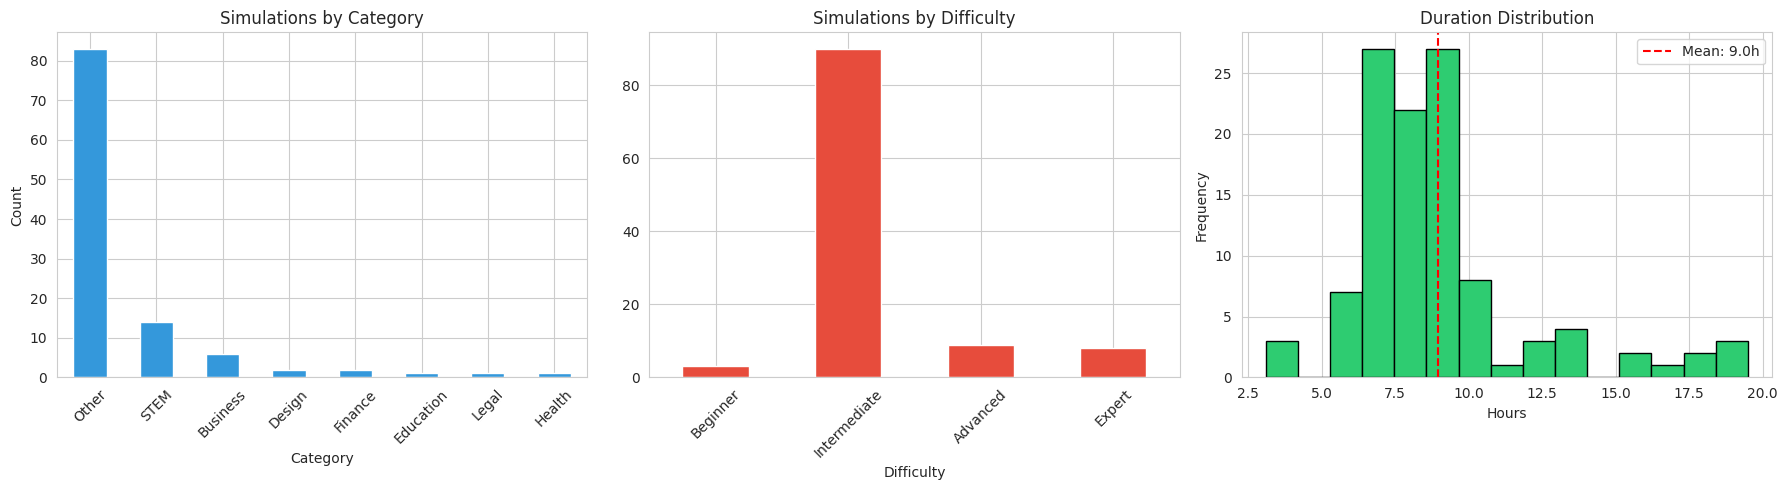


Example Simulations:


,simulation_id,simulation_title,simulation_categoria,simulation_nivel_dificultad,simulation_duracion_horas,simulation_industria,simulation_required_skills,base_career
0,sim_data_scientist,Data Scientist Virtual Experience,STEM,Intermediate,9.1,Technology,"[Data Analysis, Python, SQL, Statistics, Machi...",Data Scientist
1,sim_software_engineer,Software Engineer Virtual Experience,STEM,Advanced,13.3,Technology,"[Leadership, Problem Solving, Git, Python, SQL...",Software Engineer
2,sim_ux_designer,UX Designer Virtual Experience,Design,Advanced,13.2,Creative & Design,"[Figma, Problem Solving, UX Design, User Resea...",UX Designer
3,sim_ai_researcher,AI Researcher Virtual Experience,Other,Intermediate,7.2,General,[Problem Solving],AI Researcher
4,sim_project_manager,Project Manager Virtual Experience,Business,Intermediate,9.6,Business & Management,[Problem Solving],Project Manager


In [11]:
# Extract all unique careers
all_careers = df_all_profiles['recommended_career'].unique()
print(f"Total unique careers: {len(all_careers)}")

# Create simulation for each career
simulations = []

# Difficulty mapping based on education requirements
DIFFICULTY_RULES = {
    'STEM': ['Intermediate', 'Advanced', 'Expert'],
    'Business': ['Beginner', 'Intermediate', 'Advanced'],
    'Finance': ['Intermediate', 'Advanced', 'Expert'],
    'Health': ['Intermediate', 'Advanced'],
    'Design': ['Beginner', 'Intermediate', 'Advanced'],
    'Legal': ['Advanced', 'Expert'],
    'Education': ['Beginner', 'Intermediate']
}

# Duration ranges by difficulty
DURATION_RANGES = {
    'Beginner': (3, 6),
    'Intermediate': (6, 10),
    'Advanced': (10, 15),
    'Expert': (15, 20)
}

for career in all_careers:
    category = map_career_to_category(career)
    
    # Determine difficulty
    possible_difficulties = DIFFICULTY_RULES.get(category, ['Intermediate'])
    difficulty = random.choice(possible_difficulties)
    
    # Duration based on difficulty
    min_dur, max_dur = DURATION_RANGES[difficulty]
    duration = round(random.uniform(min_dur, max_dur), 1)
    
    # Industry from category
    industria = CATEGORY_TO_INDUSTRY.get(category, 'General')
    
    # Required skills (infer from career)
    required_skills = infer_skills_for_career(career, existing_skills=[])
    
    # Create simulation
    simulation = {
        'simulation_id': f'sim_{career.lower().replace(" ", "_")}',
        'simulation_title': f'{career} Virtual Experience',
        'simulation_categoria': category,
        'simulation_nivel_dificultad': difficulty,
        'simulation_duracion_horas': duration,
        'simulation_industria': industria,
        'simulation_required_skills': required_skills,
        'base_career': career
    }
    
    simulations.append(simulation)

df_simulations = pd.DataFrame(simulations)

print(f"\n✓ Created {len(simulations)} unique simulations")

print("\nSimulation Statistics:")
print("\nBy Category:")
print(df_simulations['simulation_categoria'].value_counts())

print("\nBy Difficulty:")
print(df_simulations['simulation_nivel_dificultad'].value_counts())

print("\nDuration Statistics:")
print(df_simulations['simulation_duracion_horas'].describe())

# Visualize simulation catalog
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Category distribution
df_simulations['simulation_categoria'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Simulations by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Difficulty distribution
difficulty_order = ['Beginner', 'Intermediate', 'Advanced', 'Expert']
df_simulations['simulation_nivel_dificultad'].value_counts().reindex(difficulty_order).plot(
    kind='bar', ax=axes[1], color='#e74c3c'
)
axes[1].set_title('Simulations by Difficulty')
axes[1].set_xlabel('Difficulty')
axes[1].tick_params(axis='x', rotation=45)

# Duration distribution
axes[2].hist(df_simulations['simulation_duracion_horas'], bins=15, color='#2ecc71', edgecolor='black')
axes[2].set_title('Duration Distribution')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Frequency')
axes[2].axvline(df_simulations['simulation_duracion_horas'].mean(), color='red', linestyle='--',
               label=f'Mean: {df_simulations["simulation_duracion_horas"].mean():.1f}h')
axes[2].legend()

plt.tight_layout()
plt.savefig(viz_dir / '04_simulation_catalog.png', dpi=150, bbox_inches='tight')
plt.show()

# Show example simulations
print("\nExample Simulations:")
display(df_simulations.head(5))

---
## Step 11: Rebalance Skills

Address the skill imbalance problem by downsampling common skills.

BEFORE Rebalancing:
Total skill occurrences: 31,633
Unique skills: 839

Top 10 skills:
  Problem Solving               :  7746
  Communication                 :  5230
  Teamwork                      :  4384
  Python                        :  1342
  Data Analysis                 :  1151
  Excel                         :   898
  SQL                           :   842
  Accounting                    :   611
  Machine Learning              :   596
  Marketing                     :   586

Rebalancing Strategy:
  Target max frequency: 1000
  Target min frequency: 150

AFTER Rebalancing:
Total skill occurrences: 27,534
Unique skills: 839

Top 10 skills:
  Problem Solving               :  6259
  Communication                 :  3834
  Teamwork                      :  3612
  Data Analysis                 :  1029
  Python                        :  1020
  Excel                         :   898
  SQL                           :   842
  Accounting                    :   611
  Machine Learning        

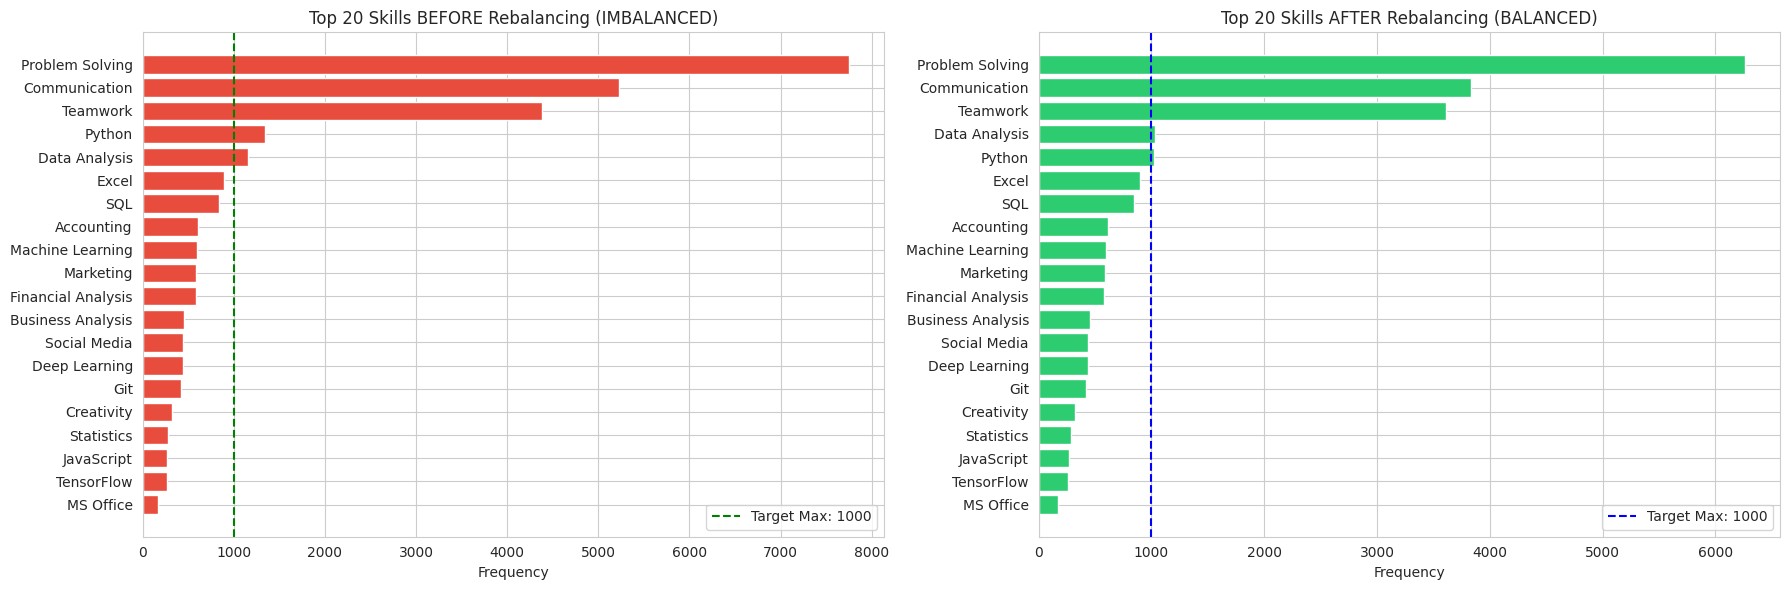


✓ Skills rebalanced successfully


In [12]:
# Collect all skills from user profiles
all_skills_from_profiles = []
for profile in all_user_profiles:
    all_skills_from_profiles.extend(profile['skills'])

# Count frequencies BEFORE rebalancing
skill_counter_before = Counter(all_skills_from_profiles)

print("BEFORE Rebalancing:")
print(f"Total skill occurrences: {len(all_skills_from_profiles):,}")
print(f"Unique skills: {len(skill_counter_before)}")
print(f"\nTop 10 skills:")
for skill, count in skill_counter_before.most_common(10):
    print(f"  {skill:30s}: {count:5d}")

# Define target distribution
TARGET_MAX_FREQUENCY = 1000  # Maximum occurrences for any skill
TARGET_MIN_FREQUENCY = 150   # Minimum occurrences for rare skills

print(f"\nRebalancing Strategy:")
print(f"  Target max frequency: {TARGET_MAX_FREQUENCY}")
print(f"  Target min frequency: {TARGET_MIN_FREQUENCY}")

# Rebalance each user's skills
for profile in all_user_profiles:
    rebalanced_skills = []
    
    for skill in profile['skills']:
        freq = skill_counter_before[skill]
        
        # Calculate keep probability
        if freq > TARGET_MAX_FREQUENCY:
            keep_prob = TARGET_MAX_FREQUENCY / freq
        else:
            keep_prob = 1.0
        
        # Keep skill based on probability
        if random.random() < keep_prob:
            rebalanced_skills.append(skill)
    
    # Ensure minimum 3 skills per user
    if len(rebalanced_skills) < 3:
        # Add back some removed skills
        missing = 3 - len(rebalanced_skills)
        removed = [s for s in profile['skills'] if s not in rebalanced_skills]
        if removed:
            rebalanced_skills.extend(random.sample(removed, min(missing, len(removed))))
    
    profile['skills'] = rebalanced_skills

# Recalculate after rebalancing
all_skills_after = []
for profile in all_user_profiles:
    all_skills_after.extend(profile['skills'])

skill_counter_after = Counter(all_skills_after)

print(f"\nAFTER Rebalancing:")
print(f"Total skill occurrences: {len(all_skills_after):,}")
print(f"Unique skills: {len(skill_counter_after)}")
print(f"\nTop 10 skills:")
for skill, count in skill_counter_after.most_common(10):
    print(f"  {skill:30s}: {count:5d}")

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before rebalancing
top_20_before = skill_counter_before.most_common(20)
skills_b = [s[0] for s in top_20_before]
counts_b = [s[1] for s in top_20_before]

axes[0].barh(skills_b, counts_b, color='#e74c3c')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Skills BEFORE Rebalancing (IMBALANCED)')
axes[0].invert_yaxis()
axes[0].axvline(TARGET_MAX_FREQUENCY, color='green', linestyle='--', label=f'Target Max: {TARGET_MAX_FREQUENCY}')
axes[0].legend()

# After rebalancing
top_20_after = skill_counter_after.most_common(20)
skills_a = [s[0] for s in top_20_after]
counts_a = [s[1] for s in top_20_after]

axes[1].barh(skills_a, counts_a, color='#2ecc71')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Skills AFTER Rebalancing (BALANCED)')
axes[1].invert_yaxis()
axes[1].axvline(TARGET_MAX_FREQUENCY, color='blue', linestyle='--', label=f'Target Max: {TARGET_MAX_FREQUENCY}')
axes[1].legend()

plt.tight_layout()
plt.savefig(viz_dir / '05_skill_rebalancing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Skills rebalanced successfully")

---
## Step 12: Create Final Skills Catalog

In [13]:
# Build final skills catalog
skills_catalog = []

for skill_id, (skill_name, count) in enumerate(skill_counter_after.most_common(), start=1):
    skills_catalog.append({
        'skill_id': skill_id,
        'skill_name': skill_name,
        'frequency': count,
        'slug': re.sub(r'[^a-z0-9]+', '-', skill_name.lower()).strip('-')
    })

df_skills_catalog = pd.DataFrame(skills_catalog)

print(f"Final Skills Catalog: {len(df_skills_catalog)} unique skills")
print(f"\nFrequency Statistics:")
print(df_skills_catalog['frequency'].describe())

print(f"\nTop 15 Skills (Final):")
display(df_skills_catalog.head(15))

# Save catalog
df_skills_catalog.to_csv(output_dir / 'skills_catalog.csv', index=False)
print(f"\n✓ Skills catalog saved to {output_dir / 'skills_catalog.csv'}")

Final Skills Catalog: 839 unique skills

Frequency Statistics:
count     839.000000
mean       32.817640
std       293.776097
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max      6259.000000
Name: frequency, dtype: float64

Top 15 Skills (Final):


,skill_id,skill_name,frequency,slug
0,1,Problem Solving,6259,problem-solving
1,2,Communication,3834,communication
2,3,Teamwork,3612,teamwork
3,4,Data Analysis,1029,data-analysis
4,5,Python,1020,python
5,6,Excel,898,excel
6,7,SQL,842,sql
7,8,Accounting,611,accounting
8,9,Machine Learning,596,machine-learning
9,10,Marketing,586,marketing



✓ Skills catalog saved to /workspace/data/processed/skills_catalog.csv


---
## Step 13: Generate Training Samples (Positive + Negative)

For each user, create:
- 1 positive sample (their recommended simulation)
- 2 negative samples (random non-matching simulations)

In [ ]:
# Create skill name → skill_id mapping
skill_to_id = {row['skill_name']: row['skill_id'] for _, row in df_skills_catalog.iterrows()}

training_samples = []

print("Generating training samples...")
print(f"  Users: {len(all_user_profiles):,}")
print(f"  Simulations: {len(simulations)}")
print(f"  Target samples: {len(all_user_profiles) * 3:,} (1 positive + 2 negative per user)")

for user in all_user_profiles:
    # Find user's recommended simulation
    positive_sim = next(
        (s for s in simulations if s['base_career'] == user['recommended_career']),
        None
    )
    
    if positive_sim is None:
        continue
    
    # ===== POSITIVE SAMPLE =====
    # Convert skills to IDs
    user_skill_ids = [skill_to_id[s] for s in user['skills'] if s in skill_to_id]
    sim_skill_ids = [skill_to_id[s] for s in positive_sim['simulation_required_skills'] if s in skill_to_id]
    
    # Calculate skill overlap
    skill_overlap = len(set(user_skill_ids) & set(sim_skill_ids))
    max_possible = max(len(user_skill_ids), len(sim_skill_ids), 1)
    skill_match_score = skill_overlap / max_possible
    
    # Calculate engagement probability
    base_score = user['base_engagement_score']
    engagement_prob = (base_score * 0.7) + (skill_match_score * 0.3)
    engagement_prob = np.clip(engagement_prob, 0.0, 1.0)
    
    # Binary label based on engagement probability
    label = 1 if engagement_prob > 0.5 else 0
    
    positive_sample = {
        # User features
        'user_id': user['user_id'],
        'user_skill_ids': user_skill_ids,
        'education_level': user['education_level'],
        'field_of_study': user['field_of_study'],
        'analytical_score': user['analytical_score'],
        'creative_score': user['creative_score'],
        'social_score': user['social_score'],
        'linguistic_score': user['linguistic_score'],
        'hands_on_score': user['hands_on_score'],
        
        # Simulation features
        'simulation_id': positive_sim['simulation_id'],
        'simulation_categoria': positive_sim['simulation_categoria'],
        'simulation_nivel_dificultad': positive_sim['simulation_nivel_dificultad'],
        'simulation_duracion_horas': positive_sim['simulation_duracion_horas'],
        'simulation_industria': positive_sim['simulation_industria'],
        'simulation_skill_ids': sim_skill_ids,
        
        # Label
        'label': label,
        'engagement_probability': engagement_prob,
        
        # Metadata
        'source_dataset': user['source_dataset'],
        'sample_type': 'positive'
    }
    
    training_samples.append(positive_sample)
    
    # ===== NEGATIVE SAMPLES (2 per user) =====
    # Get simulations from different categories
    different_category_sims = [
        s for s in simulations 
        if s['simulation_categoria'] != user['recommended_category']
    ]
    
    if len(different_category_sims) >= 2:
        negative_sims = random.sample(different_category_sims, 2)
        
        for neg_sim in negative_sims:
            neg_skill_ids = [skill_to_id[s] for s in neg_sim['simulation_required_skills'] if s in skill_to_id]
            
            # Low engagement for negative samples
            neg_engagement_prob = np.random.uniform(0.1, 0.4)
            
            negative_sample = {
                'user_id': user['user_id'],
                'user_skill_ids': user_skill_ids,
                'education_level': user['education_level'],
                'field_of_study': user['field_of_study'],
                'analytical_score': user['analytical_score'],
                'creative_score': user['creative_score'],
                'social_score': user['social_score'],
                'linguistic_score': user['linguistic_score'],
                'hands_on_score': user['hands_on_score'],
                'simulation_id': neg_sim['simulation_id'],
                'simulation_categoria': neg_sim['simulation_categoria'],
                'simulation_nivel_dificultad': neg_sim['simulation_nivel_dificultad'],
                'simulation_duracion_horas': neg_sim['simulation_duracion_horas'],
                'simulation_industria': neg_sim['simulation_industria'],
                'simulation_skill_ids': neg_skill_ids,
                'label': 0,
                'engagement_probability': neg_engagement_prob,
                'source_dataset': user['source_dataset'],
                'sample_type': 'negative'
            }
            
            training_samples.append(negative_sample)

print(f"\n✓ Generated {len(training_samples):,} training samples")

# Convert to DataFrame
df_training = pd.DataFrame(training_samples)

print(f"\nSample Type Distribution:")
print(df_training['sample_type'].value_counts())

print(f"\nLabel Distribution:")
print(df_training['label'].value_counts())
print(f"Positive rate: {df_training['label'].mean()*100:.2f}%")

print(f"\nEngagement Probability by Label:")
print(df_training.groupby('label')['engagement_probability'].describe())

---
## Step 14: Visualize Final Training Dataset

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Label distribution
df_training['label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c', '#2ecc71'])
axes[0,0].set_title('Label Distribution')
axes[0,0].set_xlabel('Label')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Not Engaged (0)', 'Engaged (1)'], rotation=0)

# Engagement probability by label
df_training.boxplot(column='engagement_probability', by='label', ax=axes[0,1])
axes[0,1].set_title('Engagement Probability by Label')
axes[0,1].set_xlabel('Label')
axes[0,1].set_ylabel('Engagement Probability')
plt.sca(axes[0,1])
plt.xticks([1, 2], ['Not Engaged (0)', 'Engaged (1)'])

# Sample type distribution
df_training['sample_type'].value_counts().plot(kind='bar', ax=axes[0,2], color=['#3498db', '#f39c12'])
axes[0,2].set_title('Sample Type Distribution')
axes[0,2].set_xlabel('Sample Type')
axes[0,2].tick_params(axis='x', rotation=45)

# Simulation category distribution
df_training['simulation_categoria'].value_counts().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Simulation Category Distribution')
axes[1,0].set_xlabel('Category')
axes[1,0].tick_params(axis='x', rotation=45)

# Difficulty distribution
difficulty_order = ['Beginner', 'Intermediate', 'Advanced', 'Expert']
df_training['simulation_nivel_dificultad'].value_counts().reindex(difficulty_order).plot(
    kind='bar', ax=axes[1,1], color='coral'
)
axes[1,1].set_title('Simulation Difficulty Distribution')
axes[1,1].set_xlabel('Difficulty')
axes[1,1].tick_params(axis='x', rotation=45)

# Source dataset distribution
df_training['source_dataset'].value_counts().plot(kind='bar', ax=axes[1,2], color='#9b59b6')
axes[1,2].set_title('Source Dataset Distribution')
axes[1,2].set_xlabel('Source')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(viz_dir / '06_final_training_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Training dataset visualized")

---
## Step 15: Encode Categorical Features

In [ ]:
# Create label encoders
encoders = {}

categorical_features = [
    'education_level',
    'field_of_study',
    'simulation_categoria',
    'simulation_nivel_dificultad',
    'simulation_industria'
]

df_encoded = df_training.copy()

print("Encoding categorical features:")
print("="*80)

for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[f'{feature}_encoded'] = le.fit_transform(df_encoded[feature])
    encoders[feature] = le
    
    print(f"\n{feature}:")
    print(f"  Unique values: {len(le.classes_)}")
    print(f"  Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n✓ Categorical features encoded")

---
## Step 16: Create Multi-Hot Skill Vectors

In [ ]:
# Create multi-hot vectors for user skills
num_skills = len(df_skills_catalog)

print(f"Creating multi-hot skill vectors...")
print(f"  Vocabulary size: {num_skills} skills")
print(f"  Vector dimension: {num_skills}")

user_skill_vectors = []
sim_skill_vectors = []

for _, row in df_encoded.iterrows():
    # User skill vector
    user_vec = np.zeros(num_skills, dtype=np.int8)
    for skill_id in row['user_skill_ids']:
        if 1 <= skill_id <= num_skills:
            user_vec[skill_id - 1] = 1
    user_skill_vectors.append(user_vec)
    
    # Simulation skill vector
    sim_vec = np.zeros(num_skills, dtype=np.int8)
    for skill_id in row['simulation_skill_ids']:
        if 1 <= skill_id <= num_skills:
            sim_vec[skill_id - 1] = 1
    sim_skill_vectors.append(sim_vec)

# Add to dataframe
df_encoded['user_skill_vector'] = user_skill_vectors
df_encoded['sim_skill_vector'] = sim_skill_vectors

print(f"\n✓ Skill vectors created")
print(f"  Average user skills: {np.mean([v.sum() for v in user_skill_vectors]):.2f}")
print(f"  Average simulation skills: {np.mean([v.sum() for v in sim_skill_vectors]):.2f}")

---
## Step 17: Save Final Dataset

In [ ]:
# Save main dataset (without skill vectors for CSV compatibility)
df_save = df_encoded.drop(columns=['user_skill_vector', 'sim_skill_vector', 
                                     'user_skill_ids', 'simulation_skill_ids'])
df_save.to_csv(output_dir / 'unified_training_dataset.csv', index=False)
print(f"✓ Main dataset saved to {output_dir / 'unified_training_dataset.csv'}")
print(f"  Shape: {df_save.shape}")

# Save skill vectors as numpy arrays
user_skill_matrix = np.vstack(user_skill_vectors)
sim_skill_matrix = np.vstack(sim_skill_vectors)

np.save(output_dir / 'user_skill_vectors.npy', user_skill_matrix)
np.save(output_dir / 'simulation_skill_vectors.npy', sim_skill_matrix)
print(f"\n✓ Skill vectors saved")
print(f"  User skills: {user_skill_matrix.shape}")
print(f"  Simulation skills: {sim_skill_matrix.shape}")

# Save encoders
import pickle
with open(output_dir / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print(f"\n✓ Label encoders saved to {output_dir / 'label_encoders.pkl'}")

# Save simulation catalog
df_simulations.to_csv(output_dir / 'simulation_catalog.csv', index=False)
print(f"\n✓ Simulation catalog saved to {output_dir / 'simulation_catalog.csv'}")

# Save metadata
metadata = {
    'total_samples': len(df_encoded),
    'positive_samples': int(df_encoded['label'].sum()),
    'negative_samples': int((1 - df_encoded['label']).sum()),
    'positive_rate': float(df_encoded['label'].mean()),
    'num_users': len(all_user_profiles),
    'num_simulations': len(simulations),
    'num_skills': num_skills,
    'num_categories': len(df_encoded['simulation_categoria'].unique()),
    'categories': df_encoded['simulation_categoria'].unique().tolist(),
    'difficulty_levels': df_encoded['simulation_nivel_dificultad'].unique().tolist(),
    'education_levels': df_encoded['education_level'].unique().tolist(),
    'source_datasets': df_encoded['source_dataset'].value_counts().to_dict(),
    'features': {
        'user_features': [
            'user_skill_vector', 'education_level', 'field_of_study',
            'analytical_score', 'creative_score', 'social_score',
            'linguistic_score', 'hands_on_score'
        ],
        'simulation_features': [
            'simulation_skill_vector', 'simulation_categoria',
            'simulation_nivel_dificultad', 'simulation_duracion_horas',
            'simulation_industria'
        ],
        'label': 'label'
    }
}

with open(output_dir / 'dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"\n✓ Metadata saved to {output_dir / 'dataset_metadata.json'}")

---
## Step 18: Final Summary & Statistics

In [ ]:
print("="*80)
print("FINAL DATASET SUMMARY")
print("="*80)

print(f"\n📊 DATASET SIZE:")
print(f"  Total training samples: {len(df_encoded):,}")
print(f"  Unique users: {len(all_user_profiles):,}")
print(f"  Unique simulations: {len(simulations)}")
print(f"  Unique skills: {num_skills}")

print(f"\n✅ LABEL DISTRIBUTION:")
print(f"  Positive samples (engaged): {metadata['positive_samples']:,} ({metadata['positive_rate']*100:.2f}%)")
print(f"  Negative samples (not engaged): {metadata['negative_samples']:,} ({(1-metadata['positive_rate'])*100:.2f}%)")

print(f"\n📚 SOURCE BREAKDOWN:")
for source, count in metadata['source_datasets'].items():
    print(f"  {source:15s}: {count:6,} samples ({count/len(df_encoded)*100:5.2f}%)")

print(f"\n🎯 CATEGORIES:")
cat_counts = df_encoded['simulation_categoria'].value_counts()
for cat, count in cat_counts.items():
    print(f"  {cat:12s}: {count:5,} samples ({count/len(df_encoded)*100:5.2f}%)")

print(f"\n📈 DIFFICULTY LEVELS:")
diff_counts = df_encoded['simulation_nivel_dificultad'].value_counts()
for diff in ['Beginner', 'Intermediate', 'Advanced', 'Expert']:
    count = diff_counts.get(diff, 0)
    print(f"  {diff:12s}: {count:5,} samples ({count/len(df_encoded)*100:5.2f}%)")

print(f"\n🎓 EDUCATION LEVELS:")
edu_counts = df_encoded['education_level'].value_counts()
for edu, count in edu_counts.items():
    print(f"  {edu:15s}: {count:5,} samples ({count/len(df_encoded)*100:5.2f}%)")

print(f"\n🧠 LEARNING SCORES (Average):")
for score in ['analytical_score', 'creative_score', 'social_score', 'linguistic_score', 'hands_on_score']:
    avg = df_encoded[score].mean()
    std = df_encoded[score].std()
    print(f"  {score:20s}: {avg:5.1f} ± {std:4.1f}")

print(f"\n💾 OUTPUT FILES:")
print(f"  unified_training_dataset.csv      - {df_save.shape[0]:,} rows × {df_save.shape[1]} columns")
print(f"  user_skill_vectors.npy            - {user_skill_matrix.shape} (multi-hot)")
print(f"  simulation_skill_vectors.npy      - {sim_skill_matrix.shape} (multi-hot)")
print(f"  skills_catalog.csv                - {len(df_skills_catalog)} skills")
print(f"  simulation_catalog.csv            - {len(df_simulations)} simulations")
print(f"  label_encoders.pkl                - {len(encoders)} encoders")
print(f"  dataset_metadata.json             - Metadata")

print("\n" + "="*80)
print("✅ DATA UNIFICATION COMPLETE!")
print("="*80)

print("\n📊 All visualizations saved to:", viz_dir)
print("📁 All data files saved to:", output_dir)

print("\n🚀 Next Steps:")
print("  1. Review visualizations to verify data quality")
print("  2. Split dataset into train/validation/test sets")
print("  3. Feature scaling/normalization")
print("  4. Convert to MindRecord format for MindSpore")
print("  5. Train Wide&Deep model")